# 03. Segmentation & Impact

**Input:** `data/processed/experiment_medium.parquet`
**Goal:**
1. Understand where the discount effect performs best/worst.
2. Check for multiple testing issues using the Holm-Bonferroni method.
3. Prepare data for the dashboard.

**Segments:**
- `is_uk`: UK vs. non-UK
- `is_new`: new (<90 days tenure) vs. returning
- `value_segment`: high vs. low (based on monetary value median)

**Metrics per segment:**
- Conversion Rate (z-test + relative uplift)
- Revenue per customer (Welch's t-test + 95% CI)

In [1]:
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ROOT = pathlib.Path("..").resolve()
PROC = ROOT / "data" / "processed"
REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)

ALPHA = 0.05

In [14]:
exp = pd.read_parquet(PROC / "experiment_medium.parquet")
print("shape:", exp.shape)

# Error-free multi-series value_counts: calculating separately
for col in ["is_uk", "is_new", "value_segment", "group"]:
    print(f"\n--- {col} ---")
    print(exp[col].value_counts(dropna=False))

# Additional — group × segment cross-tab (balance):
for col in ["is_uk", "is_new", "value_segment"]:
    print(f"\n--- group × {col} ---")
    print(pd.crosstab(exp["group"], exp[col], normalize="index").round(4))

shape: (5841, 20)

--- is_uk ---
is_uk
True     5328
False     513
Name: count, dtype: int64

--- is_new ---
is_new
False    5247
True      594
Name: count, dtype: int64

--- value_segment ---
value_segment
low     2921
high    2920
Name: count, dtype: int64

--- group ---
group
treatment    2937
control      2904
Name: count, dtype: int64

--- group × is_uk ---
is_uk      False  True 
group                  
control   0.0888 0.9112
treatment 0.0868 0.9132

--- group × is_new ---
is_new     False  True 
group                  
control   0.8957 0.1043
treatment 0.9009 0.0991

--- group × value_segment ---
value_segment   high    low
group                      
control       0.5021 0.4979
treatment     0.4978 0.5022


## 1. Helper functions

We reuse the same tests as in Notebook 02 but apply them to each segment.

In [3]:
def two_prop_ztest(x_c, n_c, x_t, n_t):
    if n_c == 0 or n_t == 0:
        return dict(abs_diff=np.nan, rel_uplift=np.nan,
                    ci_low=np.nan, ci_high=np.nan, z=np.nan, p=np.nan,
                    p_control=np.nan, p_treatment=np.nan)
    p_c, p_t = x_c/n_c, x_t/n_t
    p_pool = (x_c + x_t) / (n_c + n_t)
    se_pool = np.sqrt(p_pool * (1-p_pool) * (1/n_c + 1/n_t))
    z = (p_t - p_c) / se_pool if se_pool > 0 else np.nan
    p_val = 2 * (1 - stats.norm.cdf(abs(z))) if not np.isnan(z) else np.nan
    se_unpooled = np.sqrt(p_c*(1-p_c)/n_c + p_t*(1-p_t)/n_t)
    diff = p_t - p_c
    ci = (diff - 1.96*se_unpooled, diff + 1.96*se_unpooled)
    return dict(p_control=p_c, p_treatment=p_t, abs_diff=diff,
                ci_low=ci[0], ci_high=ci[1], z=z, p=p_val,
                rel_uplift=diff/p_c if p_c else np.nan)

def welch_rpc(x_c: pd.Series, x_t: pd.Series):
    if len(x_c) < 2 or len(x_t) < 2:
        return dict(mean_control=np.nan, mean_treatment=np.nan,
                    abs_diff=np.nan, ci_low=np.nan, ci_high=np.nan,
                    rel_uplift=np.nan, p=np.nan)
    t, p = stats.ttest_ind(x_t, x_c, equal_var=False)
    diff = x_t.mean() - x_c.mean()
    se = np.sqrt(x_c.var(ddof=1)/len(x_c) + x_t.var(ddof=1)/len(x_t))
    return dict(mean_control=x_c.mean(), mean_treatment=x_t.mean(),
                abs_diff=diff,
                ci_low=diff - 1.96*se, ci_high=diff + 1.96*se,
                rel_uplift=diff/x_c.mean() if x_c.mean() else np.nan,
                p=p)

## 2. Segment-level analysis

Breakdown by each segmentation attribute. One row = one segment + metric.

In [4]:
SEGMENTS = {
    "is_uk":         {True: "UK", False: "Non-UK"},
    "is_new":        {True: "New", False: "Returning"},
    "value_segment": {"high": "High value", "low": "Low value"},
}

rows = []
for seg_col, label_map in SEGMENTS.items():
    for seg_val, seg_label in label_map.items():
        sub = exp[exp[seg_col] == seg_val]
        c = sub[sub.group == "control"]
        t = sub[sub.group == "treatment"]

        # Conversion
        conv = two_prop_ztest(
            x_c=c.converted.sum(), n_c=len(c),
            x_t=t.converted.sum(), n_t=len(t),
        )

        # RPC
        rpc = welch_rpc(c.revenue_sim, t.revenue_sim)

        rows.append({
            "segment_group": seg_col,
            "segment":       seg_label,
            "n_control":     len(c),
            "n_treatment":   len(t),
            # conversion
            "conv_c":        conv["p_control"],
            "conv_t":        conv["p_treatment"],
            "conv_abs":      conv["abs_diff"],
            "conv_rel":      conv["rel_uplift"],
            "conv_ci_low":   conv["ci_low"],
            "conv_ci_high":  conv["ci_high"],
            "conv_p":        conv["p"],
            # RPC
            "rpc_c":         rpc["mean_control"],
            "rpc_t":         rpc["mean_treatment"],
            "rpc_abs":       rpc["abs_diff"],
            "rpc_rel":       rpc["rel_uplift"],
            "rpc_ci_low":    rpc["ci_low"],
            "rpc_ci_high":   rpc["ci_high"],
            "rpc_p":         rpc["p"],
        })

seg = pd.DataFrame(rows)
display(seg[["segment_group","segment","n_control","n_treatment",
             "conv_c","conv_t","conv_rel","conv_p",
             "rpc_c","rpc_t","rpc_rel","rpc_p"]])

,segment_group,segment,n_control,n_treatment,conv_c,conv_t,conv_rel,conv_p,rpc_c,rpc_t,rpc_rel,rpc_p
0,is_uk,UK,2646,2682,0.1187,0.1361,0.1468,0.0565,52.5895,54.4530,0.0354,0.7348
1,is_uk,Non-UK,258,255,0.1550,0.1490,-0.0388,0.8494,109.2052,102.6569,-0.0600,0.8255
2,is_new,New,303,291,0.1551,0.1787,0.1520,0.4408,69.5569,48.2399,-0.3065,0.1915
3,is_new,Returning,2601,2646,0.1180,0.1327,0.1239,0.1098,56.2288,59.7818,0.0632,0.5554
4,value_segment,High value,1458,1462,0.1612,0.1799,0.1161,0.1789,88.0967,93.3213,0.0593,0.6110
5,value_segment,Low value,1446,1475,0.0823,0.0949,0.1533,0.2303,26.8893,24.2607,-0.0978,0.5580


## 3. Holm-Bonferroni correction

We adjust the p-values **within each family of tests**:
- family 1: all segment-level tests for Conversion;
- family 2: all segment-level tests for RPC.

In [5]:
def holm_bonferroni(p_values):
    """Returns an array of adjusted p-values using the Holm-Bonferroni method."""
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    adj = np.empty(n)
    running_max = 0.0
    for i, idx in enumerate(order):
        val = (n - i) * p[idx]
        running_max = max(running_max, val)
        adj[idx] = min(running_max, 1.0)
    return adj

seg["conv_p_adj"] = holm_bonferroni(seg["conv_p"].fillna(1))
seg["rpc_p_adj"]  = holm_bonferroni(seg["rpc_p"].fillna(1))
seg["conv_sig"]   = np.where(seg["conv_p_adj"] < ALPHA, "✅", "—")
seg["rpc_sig"]    = np.where(seg["rpc_p_adj"]  < ALPHA, "✅", "—")

display(seg[["segment","conv_p","conv_p_adj","conv_sig","rpc_p","rpc_p_adj","rpc_sig"]])

,segment,conv_p,conv_p_adj,conv_sig,rpc_p,rpc_p_adj,rpc_sig
0,UK,0.0565,0.3393,—,0.7348,1.0000,—
1,Non-UK,0.8494,0.8816,—,0.8255,1.0000,—
2,New,0.4408,0.8816,—,0.1915,1.0000,—
3,Returning,0.1098,0.5491,—,0.5554,1.0000,—
4,High value,0.1789,0.7156,—,0.6110,1.0000,—
5,Low value,0.2303,0.7156,—,0.5580,1.0000,—


## 4. Forest plot — RPC uplift с 95% CI

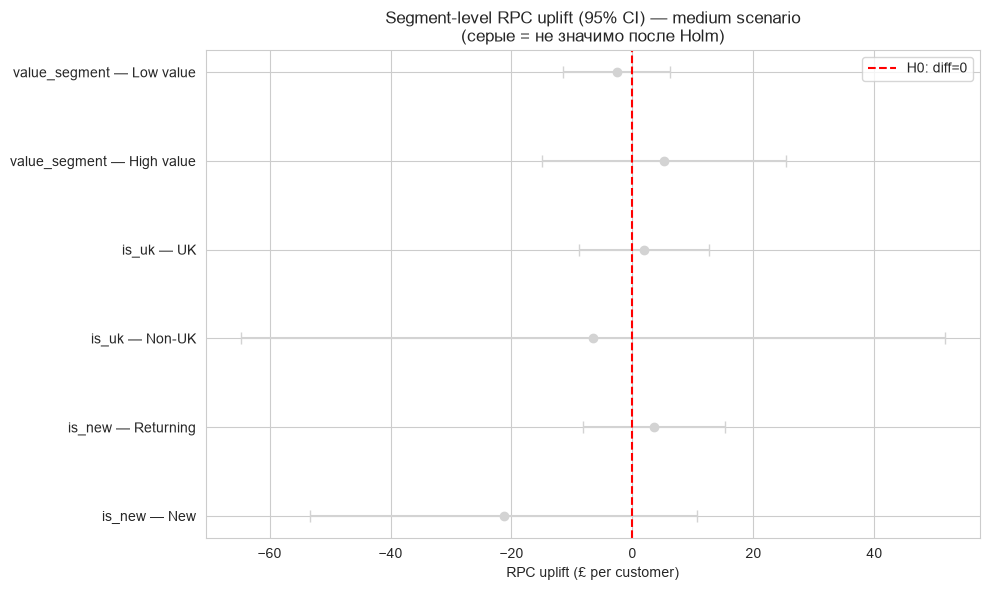

In [6]:
plot_df = seg.sort_values(["segment_group","segment"]).reset_index(drop=True)
y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(10, 6))
for i, row in plot_df.iterrows():
    sig = row["rpc_sig"] == "✅"
    color = "steelblue" if sig else "lightgray"
    ax.errorbar(
        x=row["rpc_abs"], y=i,
        xerr=[[row["rpc_abs"] - row["rpc_ci_low"]],
              [row["rpc_ci_high"] - row["rpc_abs"]]],
        fmt="o", color=color, capsize=4,
    )
ax.axvline(0, color="red", linestyle="--", label="H0: diff=0")
ax.set_yticks(y)
ax.set_yticklabels([f"{r.segment_group} — {r.segment}" for _, r in plot_df.iterrows()])
ax.set_xlabel("RPC uplift (£ per customer)")
ax.set_title("Segment-level RPC uplift (95% CI) — medium scenario\n(серые = не значимо после Holm)")
ax.legend()
plt.tight_layout(); plt.show()

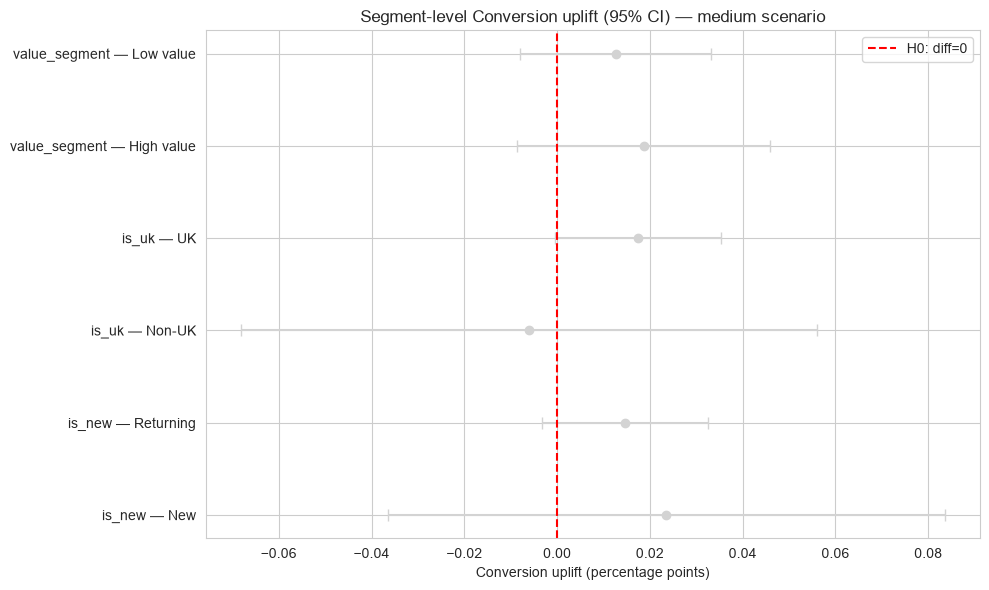

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for i, row in plot_df.iterrows():
    sig = row["conv_sig"] == "✅"
    color = "seagreen" if sig else "lightgray"
    ax.errorbar(
        x=row["conv_abs"], y=i,
        xerr=[[row["conv_abs"] - row["conv_ci_low"]],
              [row["conv_ci_high"] - row["conv_abs"]]],
        fmt="o", color=color, capsize=4,
    )
ax.axvline(0, color="red", linestyle="--", label="H0: diff=0")
ax.set_yticks(y)
ax.set_yticklabels([f"{r.segment_group} — {r.segment}" for _, r in plot_df.iterrows()])
ax.set_xlabel("Conversion uplift (percentage points)")
ax.set_title("Segment-level Conversion uplift (95% CI) — medium scenario")
ax.legend()
plt.tight_layout(); plt.show()

## 5. Heatmap: relative uplift across all segments

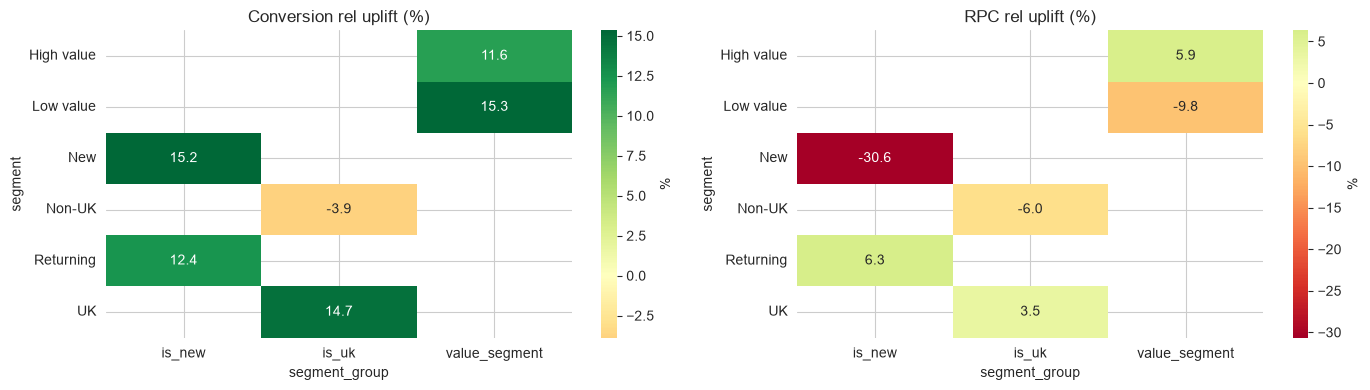

In [9]:
heat = seg.pivot_table(
    index="segment", columns="segment_group",
    values=["conv_rel", "rpc_rel"],
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, title in zip(
    axes,
    ["conv_rel", "rpc_rel"],
    ["Conversion rel uplift (%)", "RPC rel uplift (%)"],
):
    data = seg.pivot(index="segment", columns="segment_group", values=metric) * 100
    sns.heatmap(data, annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=ax,
                cbar_kws={"label": "%"})
    ax.set_title(title)
plt.tight_layout(); plt.show()

## 6. Best / worst segments - quick conclusions

In [11]:
print("=" * 70)
print("Top 3 segments by RPC uplift (significant):")
print("=" * 70)
top = seg[seg.rpc_sig=="✅"].sort_values("rpc_rel", ascending=False).head(3)
print(top[["segment_group","segment","rpc_c","rpc_t","rpc_rel","rpc_p_adj"]].to_string(index=False))

print("\n" + "=" * 70)
print("Segments with negative or zero RPC uplift:")
print("=" * 70)
neg = seg[seg.rpc_rel <= 0]
if len(neg):
    print(neg[["segment_group","segment","rpc_rel","rpc_p_adj"]].to_string(index=False))
else:
    print("No — all segments are in the black.")

print("\n" + "=" * 70)
print("Comparison of segments WITHIN a single axis (for interpretation):")
print("=" * 70)
for col in SEGMENTS:
    pivot = seg[seg.segment_group==col][["segment","rpc_rel","conv_rel"]]
    print(f"\n--- {col} ---")
    print(pivot.to_string(index=False))

Top 3 segments by RPC uplift (significant):
Empty DataFrame
Columns: [segment_group, segment, rpc_c, rpc_t, rpc_rel, rpc_p_adj]
Index: []

Segments with negative or zero RPC uplift:
segment_group   segment  rpc_rel  rpc_p_adj
        is_uk    Non-UK  -0.0600     1.0000
       is_new       New  -0.3065     1.0000
value_segment Low value  -0.0978     1.0000

Comparison of segments WITHIN a single axis (for interpretation):

--- is_uk ---
segment  rpc_rel  conv_rel
     UK   0.0354    0.1468
 Non-UK  -0.0600   -0.0388

--- is_new ---
  segment  rpc_rel  conv_rel
      New  -0.3065    0.1520
Returning   0.0632    0.1239

--- value_segment ---
   segment  rpc_rel  conv_rel
High value   0.0593    0.1161
 Low value  -0.0978    0.1533


## 7. Export

Output to `reports/`:
- `segments_summary.csv` — full table for the dashboard;
- `segments_for_dashboard.csv` — minimal set of columns.

In [13]:
seg.to_csv(REPORTS / "segments_summary.csv", index=False)
print("saved:", REPORTS / "segments_summary.csv")

dash_cols = ["segment_group","segment","n_control","n_treatment",
             "conv_c","conv_t","conv_rel","conv_p_adj","conv_sig",
             "rpc_c","rpc_t","rpc_rel","rpc_p_adj","rpc_sig"]
seg[dash_cols].to_csv(REPORTS / "segments_for_dashboard.csv", index=False)
print("saved:", REPORTS / "segments_for_dashboard.csv")

saved: C:\Users\Yana\Desktop\discount-ab-test-evaluation\reports\segments_summary.csv
saved: C:\Users\Yana\Desktop\discount-ab-test-evaluation\reports\segments_for_dashboard.csv
